This notebook tests how a learnable PE affects model-brain alignment within primary visual cortex using RSA.

**Prerequisites:** **Data inputs:** Model comparison statistics for both `2dpe` and `learn-*` PE variants under `processed_data/pe-*.csv`, fMRI RDMs under `processed_data/fmri_rdms/`.

**Generating scripts:** `run_transformer.py` trains models with different PE variants; `run_RSA.py` runs the RSA pipeline; `run_stats.py` computes permutation-based statistics.


# Influence of Positional encoding
- examines model performance with a learnable PE
- examines brain-transformer alignment in V1 (where we show brain-PE alignment in the prior analysis)

In [ ]:
pe_descs = ["learn-0.1", "learn-0.2", "learn-0.3", "learn-0.4", "learn-0.5",
            "learn-0.6", "learn-0.7", "learn-0.8", "learn-0.9", "learn-1.0",
            "learn-1.1", "learn-1.2", "learn-1.3", "learn-1.4", "learn-1.5",
            "learn-1.6", "learn-1.7", "learn-1.8", "learn-1.9", "learn-2.0"]

## Model performance

In [ ]:
import shutil
from lstnn.dataset import get_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

LST_puzzle_ds = get_dataset('../processed_data/puzzle_data_original.csv')

# model parameters
dropout = 0.0
epoch = 4000 # final training step
layer = 4
attnhead = 1
wdecay = 0.0
model_label = 'BERT'
curriculum = 'All'
seeds = [2235, 6312, 6068, 9742, 8880, 2197, 669, 6256, 3309, 2541, 8643, 7785, 195, 6914, 29]

device = 'cpu'

# model params
nblocks = [4]
dropout = 0.0
hidden_size = 160 
learning_rate = 0.0001
training_acc_cutoff = 0.0
cutoff_length = 0  # how many epochs must the model sustain the accuracy cutoff?
last_epoch = 4000
checkpoint_freq = 200
df = []
for pe in pe_descs:
    #petype = 'absolute2d'
    #pestr = '2dpe'
    resultdir = f"../processed_data/ito_models/"
    modelname = f"model-{model_label}_" \
                f"pe-{pe}_" \
                f"nl-{layer}_" \
                f"do-{dropout}_" \
                f"wd-{wdecay}_" \
                f"at-{attnhead}_" \
                f"hs-{hidden_size}_" \
                f"curr-{curriculum}_" \
                f"lr-{learning_rate}_" \
                f"co-{training_acc_cutoff}_" \
                f"col-{cutoff_length}/"

    for seed in seeds:
        checkpoint = f"s-{seed}_" \
                    f"e-{epoch}"
        fname = resultdir + modelname + checkpoint +'.csv'

        _df = pd.read_csv(fname)
        _df['seed'] = seed
        _df["pe"] = pe
        df.append(_df)
df = pd.concat(df)
df.head()
performance_df = df.copy()

# Basic performance plots

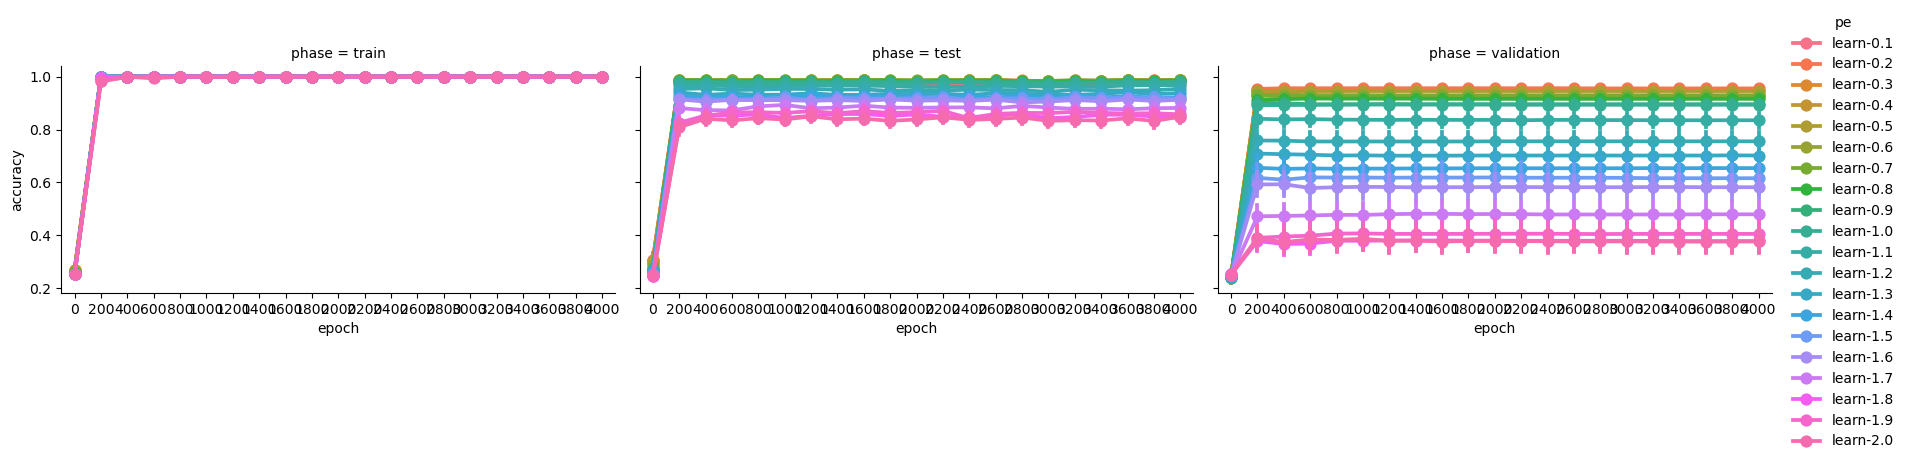

In [ ]:
import seaborn as sns
sns.catplot(data=df, x="epoch", col="phase", hue="pe", y="accuracy", kind="point", height=4, aspect=1.5)

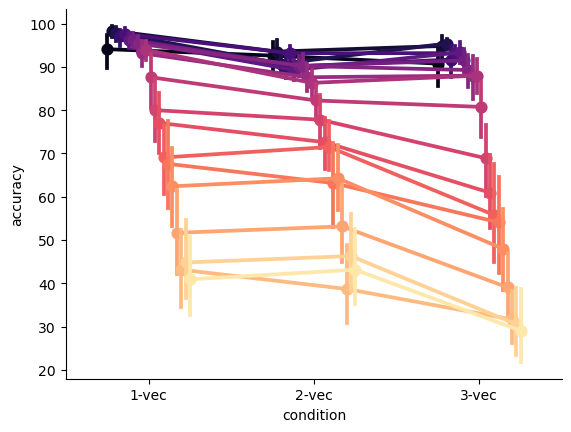

In [ ]:
# plot condition-wise test
plot_df = df.loc[(df["epoch"] == 4000)
                & (df["phase"] == "validation")
                & (df['condition'] != 'average')].reset_index()
plot_df["accuracy"] = plot_df["accuracy"] * 100
plot_df.replace("binary", "1-vec", inplace=True)
plot_df.replace("ternary", "2-vec", inplace=True)
plot_df.replace("quaternary", "3-vec", inplace=True)
sns.pointplot(data=plot_df,
            x='condition', y='accuracy', palette="magma", hue="pe",
            order=["1-vec", "2-vec", "3-vec"], dodge=True,
            legend=False)
sns.despine()
plt.show()

# Brain - PE alignment
 - Get region of interest from the main (2dpe) results (i.e., bilateral V1) and look at the overall brain-ANN alignment

In [ ]:
# get ROI
import pandas as pd
from lstnn.parcellation import Parcellation

# parameters
fmethod = "crossnobis" # "crossnobis"
amethod = "euclidean"
cmethod = "corr" 
epoch = 4000
atlas = "Glasser"

if atlas == "Glasser":
    cortex = 'Glasser'
    cortex_res = None
    scale = 1
elif atlas == "Schaefer":
    cortex = 'Schaefer'
    cortex_res = 400
    scale = 1
parc = Parcellation(cortex=cortex, cortex_res=cortex_res, scale=scale)

# load all the PE data
n_perms = 10  # note the low number of perms; not testing against null distribution here, just want to see the pattern of results across PEs
df_list = []
for pe_desc in pe_descs:
    in_file = f"../processed_data/pe-{pe_desc}"
    in_file += f"_fmethod-{fmethod}_amethod-{amethod}_cmethod-{cmethod}"
    in_file += f"_epoch-{epoch}_nperms-{n_perms}_stats.csv"
    df_list.append(pd.read_csv(in_file))
pe_df = pd.concat(df_list)
pe_df.head()

,stat,permutation,compare_method,model,parcel,it,pe,fmethod,cmethod,amethod,epoch,p_FDR,percentile,network
0,0.067595,False,corr,pe_layer0,HIP-rh,0,learn-0.1,crossnobis,corr,euclidean,4000,1.0,1.0,NaN
1,0.030235,False,corr,pe_layer1,HIP-rh,0,learn-0.1,crossnobis,corr,euclidean,4000,1.0,0.8,NaN
2,0.010958,False,corr,pe_layer2,HIP-rh,0,learn-0.1,crossnobis,corr,euclidean,4000,1.0,0.9,NaN
3,-0.001665,False,corr,pe_layer3,HIP-rh,0,learn-0.1,crossnobis,corr,euclidean,4000,1.0,0.6,NaN
4,0.030811,False,corr,pe_avg,HIP-rh,0,learn-0.1,crossnobis,corr,euclidean,4000,1.0,1.0,NaN


## Examine relationship in V1

In [ ]:
from scipy.stats import spearmanr
pe_rois = ['R_V1_ROI', 'R_V2_ROI','R_V3_ROI','L_V1_ROI','L_V2_ROI','L_V3_ROI']

data = pe_df.copy()
data[["pe_desc", "pe_value"]] = data.pe.str.split("-", n=1, expand=True)
data = data.loc[(data.parcel.isin(pe_rois))
                & (data.model == "pe_avg")].reset_index()
data = data.groupby("pe_value").mean(numeric_only=True).reset_index()
data['pe_value'] = data['pe_value'].astype(float)
print(spearmanr(data.pe_value, data.stat))
data.head()

SignificanceResult(statistic=-0.8165413533834586, pvalue=1.1247209263971732e-05)


,pe_value,index,stat,permutation,it,epoch,p_FDR,percentile
0,0.1,1629.0,0.130906,0.0,0.0,4000.0,0.0,1.0
1,0.2,1629.0,0.163567,0.0,0.0,4000.0,0.0,1.0
2,0.3,1629.0,0.163092,0.0,0.0,4000.0,0.0,1.0
3,0.4,1629.0,0.158422,0.0,0.0,4000.0,0.0,1.0
4,0.5,1629.0,0.146861,0.0,0.0,4000.0,0.0,1.0


/tmp/ipykernel_2149277/105055863.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[["pe_desc", "pe_value"]] = data.pe.str.split("-", n=1, expand=True)
/tmp/ipykernel_2149277/105055863.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[["pe_desc", "pe_value"]] = data.pe.str.split("-", n=1, expand=True)
/tmp/ipykernel_2149277/105055863.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

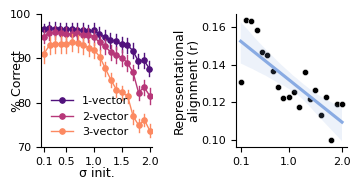

In [ ]:

from matplotlib.ticker import FormatStrFormatter

fig, axs = plt.subplots(1, 2, figsize=(3.7, 2), tight_layout=True)

ax = axs[0]
df = performance_df.copy()

# overall accuracy plot
data = df.loc[(df.phase == "test") & (df.condition != "average")]
data[["pe_desc", "pe_value"]] = data.pe.str.split("-", n=1, expand=True)
data['pe_value'] = data['pe_value'].astype(float)
data.accuracy = data.accuracy * 100
data.replace("binary", "1", inplace=True)
data.replace("ternary", "2", inplace=True)
data.replace("quaternary", "3", inplace=True)
sns.pointplot(data, x="pe_value", y="accuracy", hue_order=["1", "2", "3"],
              hue="condition", palette="magma", dodge=True, markersize=4, lw=1,
              ax=ax,
              legend=True)


# Customize legend
handles, labels = ax.get_legend_handles_labels()
custom_labels = ['1-vector', '2-vector', '3-vector']  # New labels

ax.legend(
    handles=handles,  # Skip automatic "hue" title entry
    labels=custom_labels,
    fontsize=8,
    frameon=False,  # No border
    title=None
)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_ylabel("% Correct", fontsize=9, labelpad=-10)
ax.set_xlabel("σ init.", fontsize=9, labelpad=0)
ax.set_xticks([0, 4, 9, 14, 19], [0.1, 0.5, 1.0, 1.5, 2.0])
ax.set_ylim([70, 100])
ax.set_yticks(range(70, 101, 10))
sns.despine(ax=ax)


ax = axs[1]
network = "Unimodal"

# gather relevant data
data = pe_df.copy()
data[["pe_desc", "pe_value"]] = data.pe.str.split("-", n=1, expand=True)
data = data.loc[(data.parcel.isin(pe_rois))
                & (data.model == "pe_avg")].reset_index()
data = data.groupby("pe_value").mean(numeric_only=True).reset_index()
data['pe_value'] = data['pe_value'].astype(float)

# scatter plot
sns.scatterplot(data=data, x="pe_value", y="stat", color="k", legend=False, ax=ax, s=20)

# regression line
sns.regplot(data=data, x="pe_value", y="stat", color=(0.537, 0.671, 0.890), scatter=False, ax=ax)

# parameters
ax.tick_params(axis='both', which='major', labelsize=8)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_xticks([0.1, 1.0, 2.0], [0.1, 1.0, 2.0])
ax.set_xlabel("")    
ax.set_ylabel("Representational\nalignment (r)", fontsize=9, labelpad=0)
sns.despine(ax=ax)
plt.show()

# Statistics

In [ ]:
import pingouin as pg
# mixed anova with complexity
# average performance across seeds correlation
data = df.loc[(df.phase=="validation") & (df.condition!="average") & (df.epoch == 4000)]
data[["pe_desc", "pe_value"]] = data.pe.str.split("-", n=1, expand=True)
data['pe_value'] = data['pe_value'].astype(float)
pd.set_option('display.float_format', lambda x: '%.5f' % x)
display(pg.rm_anova(data=data, dv="accuracy", within=["condition", "pe_value"], subject="seed", detailed=True))

/tmp/ipykernel_2149277/3667339568.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[["pe_desc", "pe_value"]] = data.pe.str.split("-", n=1, expand=True)
/tmp/ipykernel_2149277/3667339568.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[["pe_desc", "pe_value"]] = data.pe.str.split("-", n=1, expand=True)
/tmp/ipykernel_2149277/3667339568.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,condition,1.08916,2,28,0.54458,65.70718,0.00000,0.00000,0.07416,0.93617
1,pe_value,38.15891,19,266,2.00836,65.92909,0.00000,0.00000,0.73728,0.24429
2,condition * pe_value,0.83622,38,532,0.02201,5.85063,0.00000,0.00056,0.05794,0.10404
